In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'torch', 'torchvision']
imports = {'pillow': 'PIL'}
pinned = {}
fallbacks = {'torch': 'torch==2.11.0', 'torchvision': 'torchvision==0.26.0'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "8cd319b4f2187b6b29bb69603a96460fc325a975"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/8cd319b4f2187b6b29bb69603a96460fc325a975/d2l"
for name in ('__init__.py', 'torch.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# DeltaNet: Memory That Edits

Read down the write column of the table one more time. Seven
models, three research lineages, and every write is an addition: whatever
$\mathbf{k}_t \mathbf{v}_t^\top$ says, the memory takes it on top of what is
already there. The previous section measured what crowding does to such a
memory and built the decay ladder to manage it, but decay is indiscriminate:
to weaken one stale entry, the model must weaken everything. This section
changes the write rule instead. The fix, proposed for exactly this failure
by @Schlag.Irie.Schmidhuber.2021, is to *read before writing*: look
up what the memory currently returns for $\mathbf{k}_t$, subtract it, and
write only the correction. We first isolate the failure the additive write
cannot escape, with a memory whose entries are *overwritten* rather than
merely accumulated. We then derive the corrective write, the *delta rule*,
and find that it is one step of gradient descent on a recall loss, taken
inside the forward pass. A memory whose transition is no longer diagonal
resists the chunked training schedule of that section, so we
rebuild that schedule around a triangular solve; with a decay gate added
back we arrive at Gated DeltaNet, the cell inside several current
production models, and train it on our language-modeling scoreboard.
Finally we ask what the new transition can *compute*, and meet a capability
that no model of that section has: state tracking.

*Prerequisites: the matrix-state recurrence and its capacity law
(that section, the equation), the chunked
training schedule of that section, and the optimizer
vocabulary of that section, in particular what "decoupled"
weight decay means (that section). The training cells use a GPU
when one is available; the identity checks run anywhere.*

In [1]:
%matplotlib inline
from d2l import torch as d2l
import numpy as np
import time
import torch
from torch import nn
import torch.nn.functional as F

## The Trouble with Adding

The capacity law of that section blamed *crowding*: store
more unit-norm pairs than the key dimension and reads drown in the
interference term of the equation. There is a second
failure, and it survives even when crowding is engineered away. Suppose the
keys are few and mutually orthogonal, so that interference between
*different* keys is exactly zero, but the stream keeps *re-binding* old
keys to new values: today's stock price under the same ticker, a variable
reassigned in code, a character's location as a story moves on. An additive
memory handles re-binding badly, because addition cannot replace. After $R$
writes to the same key $\mathbf{k}$, the Hebbian state holds

$$
\mathbf{S}^\top \mathbf{k}
= \mathbf{v}^{(1)} + \mathbf{v}^{(2)} + \cdots + \mathbf{v}^{(R)}:
$$

every value ever filed under $\mathbf{k}$, superposed, with the current one
enjoying no privilege over the stale ones. A reader who wants the *latest*
binding is reduced to guessing among $R$ candidates.

The corrective write repairs exactly this. Before writing, retrieve what
the memory currently returns for the key; subtract it; then write. For
now we state the repair operationally, with everything it does visible in
the code below, and derive it properly in the next section:

$$
\mathbf{S}_t
= \mathbf{S}_{t-1}
+ \mathbf{k}_t \big(\mathbf{v}_t - \mathbf{S}_{t-1}^\top \mathbf{k}_t\big)^\top .
$$

For a unit-norm key this *replaces* the stored value: reading back
immediately after the write returns $\mathbf{v}_t$ exactly, however many
bindings preceded it. The experiment below makes the contrast quantitative.
We hand-build both memories, with no training anywhere: $8$ orthonormal
keys in $64$ dimensions (orthonormal so that cross-key interference is zero
by construction and staleness is the *only* effect in view; unit-norm keys
are also what the equation assumes), values drawn from a
codebook of $32$ unit vectors, $R$ writes per key in shuffled order. After
the stream, we read every key and decode by the nearest codebook entry,
scoring a hit only if the memory returns the key's *latest* value.

writes/key   Hebbian   delta
         1     1.000   1.000
         2     0.510   1.000
         4     0.299   1.000
         8     0.217   1.000


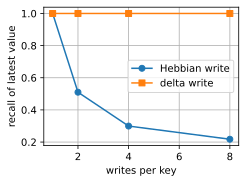

In [2]:
rng = np.random.default_rng(0)

def overwrite_recall(rule, reps, num_keys=8, num_values=32, d=64, trials=200):
    """Recall of the latest value bound to each key, after R writes per key."""
    accs = []
    for R in reps:
        correct = total = 0
        for _ in range(trials):
            K = np.linalg.qr(rng.standard_normal((d, num_keys)))[0].T
            codebook = rng.standard_normal((num_values, d))
            codebook /= np.linalg.norm(codebook, axis=1, keepdims=True)
            writes = [(k, rng.integers(num_values)) for k in range(num_keys)
                      for _ in range(R)]
            rng.shuffle(writes)
            latest, S = {}, np.zeros((d, d))
            for kk, vv in writes:
                k, v = K[kk], codebook[vv]
                latest[kk] = vv
                if rule == 'delta':
                    S = S + np.outer(k, v - S.T @ k)   # Erase, then write
                else:
                    S = S + np.outer(k, v)             # Superimpose
            for kk in range(num_keys):
                read = S.T @ K[kk]
                correct += (codebook @ read).argmax() == latest[kk]
                total += 1
        accs.append(correct / total)
    return accs

reps = [1, 2, 4, 8]
hebbian, delta = (overwrite_recall(r, reps) for r in ('hebbian', 'delta'))
print(f"{'writes/key':>10} {'Hebbian':>9} {'delta':>7}")
for row in zip(reps, hebbian, delta):
    print('{:>10} {:>9.3f} {:>7.3f}'.format(*row))
assert min(delta) > 0.99, 'delta write must recall the latest value exactly'
assert hebbian[-1] < 0.4, 'Hebbian recall must collapse under overwrites'
d2l.plot(reps, [hebbian, delta], 'writes per key', 'recall of latest value',
         legend=['Hebbian write', 'delta write'], fmts=('-o', '-s'))

The additive memory collapses just as the superposition argument predicts:
recall roughly halves by two writes per key and is down to about $0.2$ by
eight, close to picking at random among the values superposed on the key.
The corrective write holds recall at $1.000$ at every overwrite count, and
not approximately: with $\beta = 1$ and orthonormal keys, each write
replaces the row it addresses and touches nothing else, so the last write
always wins. Note what this experiment does *not* show: with only $8$
orthogonal keys there is no crowding, so the decay ladder of
that section would not help here. Decay discounts by
*age*; the failure is indexed by *key*.

### Trained Models Hit the Same Ceiling

A fair objection: no trained model is forced to use its memory the way we
just hand-operated it. Perhaps gradient descent, given an additive memory
and a task full of re-bindings, finds some encoding that sidesteps
superposition. So we let it try. The task generator below emits sequences
with a write phase, $R$ re-bindings of each of $8$ keys in shuffled order,
followed by a query phase asking for each key's latest value; the model is
trained end-to-end on cross-entropy over its answers.

In [3]:
def make_task(num_seqs, num_keys=8, num_values=16, R=4, seed=0):
    """R shuffled writes per key, then one query per key for its latest value."""
    task_rng = np.random.default_rng(seed)
    W = num_keys * R
    QUERY = num_values                     # A reserved "query" content token
    keys = np.zeros((num_seqs, W + num_keys), np.int64)
    vals = np.full((num_seqs, W + num_keys), QUERY, np.int64)
    tgt = np.full((num_seqs, W + num_keys), -1, np.int64)
    for b in range(num_seqs):
        ks = np.tile(np.arange(num_keys), R)
        vs = task_rng.integers(0, num_values, W)
        perm = task_rng.permutation(W)
        ks, vs = ks[perm], vs[perm]
        keys[b, :W], vals[b, :W] = ks, vs
        latest = {int(k): int(v) for k, v in zip(ks, vs)}
        qorder = task_rng.permutation(num_keys)
        keys[b, W:] = qorder
        tgt[b, W:] = [latest[int(k)] for k in qorder]
    return keys, vals, tgt                 # tgt = -1 outside the query phase

The model is deliberately small: one matrix-memory layer, one MLP block, a
classification head. One design decision is load-bearing, and we learned it
the hard way. The write *address*, the projections producing
$\mathbf{q}_t$, $\mathbf{k}_t$, and $\beta_t$, must be computed from the
key token alone, and the *content* $\mathbf{v}_t$ from the value token
alone. Give the address projection access to the value token and a trained
Hebbian model escapes superposition entirely, by assigning every
(key, value) *pair* its own private address so that no two writes ever
collide; recall stops distinguishing the two rules. That escape is itself
instructive, superposition only binds when addresses are reused, but it
dodges the question we are asking. Real linear-attention layers offer no
such dodge at this task's scale: $\mathbf{q}$, $\mathbf{k}$, $\mathbf{v}$
are all projections of the same token embedding, so a model that answers
"what is ticker X now" must address by the ticker. Our split enforces the
shared-address regime we set out to measure.

In [4]:
class MemoryModel(nn.Module):
    """One matrix-memory layer plus an MLP block; address from the key only."""
    def __init__(self, num_keys, num_values, rule, d=64, d_head=48):
        super().__init__()
        self.rule = rule
        self.key_emb = nn.Embedding(num_keys, d)
        self.val_emb = nn.Embedding(num_values + 1, d)
        self.W_q = nn.Linear(d, d_head, bias=False)   # Address: from key only
        self.W_k = nn.Linear(d, d_head, bias=False)
        self.W_beta = nn.Linear(d, 1)
        self.W_v = nn.Linear(d, d_head, bias=False)   # Content: from value only
        self.W_o = nn.Linear(d_head, d, bias=False)
        self.ln1, self.ln2 = nn.LayerNorm(d), nn.LayerNorm(d)
        self.mlp = nn.Sequential(nn.Linear(d, 4 * d), nn.GELU(),
                                 nn.Linear(4 * d, d))
        self.head = nn.Linear(d, num_values)

    def forward(self, keys, vals):
        a, c = self.key_emb(keys), self.val_emb(vals)
        q = F.normalize(self.W_q(a), dim=-1)   # x / max(|x|, 1e-12)
        k = F.normalize(self.W_k(a), dim=-1)
        v, beta = self.W_v(c), torch.sigmoid(self.W_beta(a))
        B, T, d_head = v.shape
        S = v.new_zeros(B, d_head, d_head)
        outputs = []
        for t in range(T):
            k_t, v_t = k[:, t], v[:, t]
            if self.rule == 'delta':                   # Erase, then write
                u = beta[:, t] * (v_t - torch.einsum('bkv,bk->bv', S, k_t))
            else:                                      # Hebbian: superimpose
                u = v_t
            S = S + k_t[:, :, None] * u[:, None, :]
            outputs.append(torch.einsum('bkv,bk->bv', S, q[:, t]))
        h = a + c + self.W_o(torch.stack(outputs, 1))
        h = h + self.mlp(self.ln1(h))
        return self.head(self.ln2(h))

Training is a plain Adam loop, a couple of minutes in total for the whole
sweep; the only asymmetry between the two runs is the single line that
writes the state.

In [5]:
def train_recall(rule, R, num_keys=8, num_values=16, epochs=12,
                 num_train=4096, num_val=1024, batch_size=256):
    device = d2l.try_gpu()
    torch.manual_seed(0)
    data = [torch.tensor(x, device=device)
            for x in make_task(num_train, num_keys, num_values, R, seed=1)
            + make_task(num_val, num_keys, num_values, R, seed=2)]
    Xk, Xv, y, Vk, Vv, Vy = data
    model = MemoryModel(num_keys, num_values, rule).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=3e-3)
    for epoch in range(epochs):
        for i in torch.randperm(num_train, device=device).split(batch_size):
            loss = F.cross_entropy(model(Xk[i], Xv[i]).reshape(-1, num_values),
                                   y[i].reshape(-1), ignore_index=-1)
            opt.zero_grad(); loss.backward(); opt.step()
    with torch.no_grad():
        pred, mask = model(Vk, Vv).argmax(-1), Vy != -1
        return float((pred[mask] == Vy[mask]).float().mean())

print(f"{'writes/key':>10} {'Hebbian':>9} {'delta':>7}")
final = {}
for R in [1, 2, 4, 6]:
    accs = [train_recall(rule, R) for rule in ('hebbian', 'delta')]
    final[R] = accs
    print(f'{R:>10} {accs[0]:>9.3f} {accs[1]:>7.3f}')
assert final[6][1] > 0.95, 'trained delta must keep near-perfect recall'
assert final[6][0] < 0.5, 'trained Hebbian must collapse under overwrites'

writes/key   Hebbian   delta


         1     1.000   1.000


         2     0.537   1.000


         4     0.327   1.000


         6     0.268   1.000


Training does not rescue the additive write. The trained Hebbian model
tracks the mechanistic collapse, near $0.5$ at two writes per key and
roughly $0.25$--$0.35$ by four to six, while the delta model learns a
perfect overwriting memory and stays at $1.000$ throughout. Both models
have identical parameter counts and see identical data; the entire gap is
the write rule. This synthetic failure has a production-scale echo:
*multi-query associative recall*, essentially this task embedded in
natural text, is the single synthetic that best predicts which efficient
architectures close the quality gap to attention, a diagnosis
that section takes up in earnest.

## The Delta Rule

Time to earn the equation rather than assert it. The memory's job,
when token $t$ arrives, is to associate $\mathbf{k}_t$ with
$\mathbf{v}_t$. Phrase that as an objective: the state
$\mathbf{S}$ should make the momentary *recall loss*

$$
\ell_t(\mathbf{S})
= \tfrac{1}{2}\,
\big\| \mathbf{S}^\top \mathbf{k}_t - \mathbf{v}_t \big\|^2
$$

small: reading the memory at $\mathbf{k}_t$ should return
$\mathbf{v}_t$. The gradient is

$$
\nabla_{\mathbf{S}}\, \ell_t(\mathbf{S})
= \mathbf{k}_t \big(\mathbf{S}^\top \mathbf{k}_t - \mathbf{v}_t\big)^\top,
$$

an outer product of the key with the *prediction error*, what the memory
answered minus what it should have answered. One step of gradient descent
from $\mathbf{S}_{t-1}$ with step size $\beta_t$ is

$$
\mathbf{S}_t
= \mathbf{S}_{t-1}
- \beta_t\, \mathbf{k}_t
  \big(\mathbf{k}_t^\top \mathbf{S}_{t-1} - \mathbf{v}_t^\top\big),
$$

which at $\beta_t = 1$ is exactly the repair we used above. This is the
*delta rule*, and it is old: it is the Widrow--Hoff least-mean-squares
update of adaptive filtering [@Widrow.Hoff.1960], rediscovered for
fast-weight memories by @Schlag.Irie.Schmidhuber.2021 and made
parallel, and thereby practical at modern scale, by
@Yang.Wang.Zhang.ea.2024 . Multiplying out
the equation puts it in the transition-plus-write shape of
the equation:

$$
\mathbf{S}_t
= \big(\mathbf{I} - \beta_t\, \mathbf{k}_t \mathbf{k}_t^\top\big)\,
  \mathbf{S}_{t-1}
+ \beta_t\, \mathbf{k}_t \mathbf{v}_t^\top,
\qquad
\mathbf{o}_t = \mathbf{S}_t^\top \mathbf{q}_t .
$$

The two readings teach different things. The error form
the equation is the algorithm, four lines below, and the
cheap one to run: two matrix--vector products per token, never a
$d_k \times d_k$ matrix in sight. The matrix form
the equation slots DeltaNet into the family template: the
transition $\mathbf{I} - \beta_t \mathbf{k}_t \mathbf{k}_t^\top$ is no
longer diagonal, and this section's closing pages are about what that
buys. For a unit-norm key, the update interpolates: the value stored at
$\mathbf{k}_t$ moves to $(1 - \beta_t)\,\mathbf{v}_{\textrm{old}} +
\beta_t\, \mathbf{v}_t$, so $\beta_t$, produced by a sigmoid from the
token, is a learned *write strength*, $\beta_t \approx 0$ preserving the
old binding and $\beta_t \approx 1$ replacing it, the input gate of
that section reborn as a per-token learning rate.

That last phrase is worth dwelling on, because it reframes the whole
family. Compare the Hebbian write under the same lens: adding
$\beta_t \mathbf{k}_t \mathbf{v}_t^\top$ is one gradient step on the
*alignment* objective $-\langle \mathbf{S}^\top \mathbf{k}_t,
\mathbf{v}_t\rangle$, a loss that only ever asks the read-out to grow
along $\mathbf{v}_t$, never to be *correct*, so the updates pile up
without feedback. The delta rule optimizes recall error and gets
error-correction; linear attention optimizes alignment and gets
superposition. Both are online learners running *inside* the forward pass,
at test time, with no autograd involved; they differ only in their loss.
Once seen this way, the natural question is what other optimizers one
could run in that inner loop, and that section
develops exactly that view, with the delta rule as one point, one
plain-SGD step on a least-squares loss, in a family of solvers.

One practical note before the code: all delta-rule implementations in this
chapter $L2$-normalize keys (and queries), as shipped DeltaNet variants
do. The reason is visible in the equation: along
$\mathbf{k}_t$ the transition scales the state by
$1 - \beta_t \|\mathbf{k}_t\|^2$, which for unnormalized keys and
$\beta_t$ near $1$ can exceed $1$ in magnitude and let repeated writes
amplify the state geometrically. Unit keys pin that factor to
$1 - \beta_t \in (0, 1)$: stable, and cleanly interpretable as partial
replacement.

In [6]:
def delta_recurrent(Q, K, V, beta):
    """The delta rule in the error form: read, subtract, write, read out."""
    S = Q.new_zeros(Q.shape[-1], V.shape[-1])
    outputs = []
    for t in range(Q.shape[0]):
        error = V[t] - S.T @ K[t]                # What the memory got wrong
        S = S + beta[t] * K[t][:, None] * error[None, :]
        outputs.append(S.T @ Q[t])
    return torch.stack(outputs)

def delta_recurrent_matrix(Q, K, V, beta):
    """The same update as transition-then-write, for the family template."""
    S = Q.new_zeros(Q.shape[-1], V.shape[-1])
    I = torch.eye(Q.shape[-1], device=Q.device)
    outputs = []
    for t in range(Q.shape[0]):
        S = (I - beta[t] * torch.outer(K[t], K[t])) @ S \
            + beta[t] * torch.outer(K[t], V[t])
        outputs.append(S.T @ Q[t])
    return torch.stack(outputs)

torch.manual_seed(0)
d_k, d_v, T = 64, 64, 512
Q, K, V = (torch.randn(T, d, device=d2l.try_gpu()) for d in (d_k, d_k, d_v))
K = F.normalize(K, dim=-1)                       # Unit-norm keys, throughout
beta = torch.sigmoid(torch.randn(T, device=d2l.try_gpu()))
y_delta = delta_recurrent(Q, K, V, beta)
err = (y_delta - delta_recurrent_matrix(Q, K, V, beta)).abs().max() \
    / y_delta.abs().max()
print(f'error form vs matrix form: relative deviation {float(err):.2e}')
assert err < 1e-5                  # One rule, two readings

error form vs matrix form: relative deviation 1.88e-06


## Training It: the WY Trick

The recurrence above is fine for generation, one token, constant memory,
but training wants the whole sequence at once, and here DeltaNet is
genuinely harder than everything in that section. The
chunked schedule of that section leaned on the transition
being a scalar: products of decays collapse into `segsum`, an elementwise
log-space cumulative sum. DeltaNet's transitions are the matrices
$\mathbf{I} - \beta_t \mathbf{k}_t \mathbf{k}_t^\top$, and a product of
those is not elementwise anything; materializing the cumulative products
would cost a $d_k \times d_k$ matrix multiply per token, exactly the
parallelism-killing serial chain we are trying to avoid.

The escape is to look at *what the updates share*. Write the state at the
end of a chunk of $C$ tokens, entered with state $\mathbf{S}$, in the
error form: each token contributes a rank-one write
$\mathbf{k}_t \mathbf{u}_t^\top$ with update vector
$\mathbf{u}_t = \beta_t (\mathbf{v}_t - \mathbf{S}_{t-1}^\top
\mathbf{k}_t)$. The trouble is that $\mathbf{u}_t$ depends on
$\mathbf{S}_{t-1}$, which contains every *earlier* update in the chunk.
Substituting $\mathbf{S}_{t-1} = \mathbf{S} + \sum_{s<t} \mathbf{k}_s
\mathbf{u}_s^\top$ makes the dependency explicit:

$$
\mathbf{u}_t
= \beta_t \big(\mathbf{v}_t - \mathbf{S}^\top \mathbf{k}_t\big)
- \beta_t \sum_{s<t} (\mathbf{k}_s^\top \mathbf{k}_t)\, \mathbf{u}_s .
$$

The updates couple only through the scalars
$\mathbf{k}_s^\top \mathbf{k}_t$, key overlaps we can compute for the
whole chunk in one matmul. Stack the $\mathbf{u}_t^\top$ as the rows of
$\mathbf{U} \in \mathbb{R}^{C \times d_v}$ and
the equation becomes a *unit lower triangular* linear
system,

$$
(\mathbf{I} + \mathbf{A})\, \mathbf{U}
= \mathrm{diag}(\boldsymbol{\beta})
  \big(\mathbf{V} - \mathbf{K}\mathbf{S}\big),
\qquad
A_{ts} = \beta_t\, (\mathbf{k}_t^\top \mathbf{k}_s)\;
\textrm{for } s < t, \textrm{ else } 0,
$$

solved by forward substitution, one triangular solve per chunk. The
widths matter in the accounting: forming the coupling matrix $\mathbf{A}$
is a $\mathcal{O}(C^2 d_k)$ matmul, and the forward substitution, whose
right-hand side has $d_v$ columns, costs $\mathcal{O}(C^2 d_v)$ — the
same order as the attention-shaped matmuls around it, not free.
(Numerical linear algebra veterans will recognize the
maneuver: expressing a product of rank-one modifications,
$\prod_t (\mathbf{I} - \beta_t \mathbf{k}_t \mathbf{k}_t^\top)$, through
a compact coupling matrix is the classical *WY representation* of
products of Householder-like transformations, which is why the fast form
of DeltaNet goes by that name [@Yang.Wang.Zhang.ea.2024].) With
$\mathbf{U}$ in hand, everything else is the familiar two-piece schedule
of that section: outputs are the read of the inherited
state plus a causal attention-shaped matmul against the chunk's own
updates,
$\mathbf{Y} = \mathbf{Q}\mathbf{S} +
\mathrm{tril}(\mathbf{Q}\mathbf{K}^\top)\,\mathbf{U}$,
and the state advances by $\mathbf{S} \leftarrow \mathbf{S} +
\mathbf{K}^\top \mathbf{U}$. Attention inside, recurrence across, plus
one small solve:

In [7]:
def delta_chunked(Q, K, V, beta, chunk_size=64):
    """Chunked WY form: one triangular solve per chunk, a state across chunks."""
    C = chunk_size
    Qc, Kc = Q.view(-1, C, Q.shape[-1]), K.view(-1, C, K.shape[-1])
    Vc, bc = V.view(-1, C, V.shape[-1]), beta.view(-1, C)
    I = torch.eye(C, device=Q.device)
    A = torch.tril(bc[:, :, None] * (Kc @ Kc.transpose(-1, -2)), -1)
    S = Q.new_zeros(Q.shape[-1], V.shape[-1])
    Y = []
    for c in range(Q.shape[0] // C):       # T/C boundary steps
        U = torch.linalg.solve_triangular(  # Solve against the actual RHS:
            I + A[c], bc[c][:, None] * (Vc[c] - Kc[c] @ S),
            upper=False, unitriangular=True)  # never form the inverse
        Y.append(Qc[c] @ S + torch.tril(Qc[c] @ Kc[c].T) @ U)
        S = S + Kc[c].T @ U
    return torch.cat(Y)

for chunk_size in [16, 64, 256]:
    err = (delta_chunked(Q, K, V, beta, chunk_size) - y_delta).abs().max() \
        / y_delta.abs().max()
    print(f'chunk size {chunk_size:4d}: relative deviation {float(err):.2e}')
    assert err < 1e-3                      # Chunked == recurrence

chunk size   16: relative deviation 3.00e-07
chunk size   64: relative deviation 4.03e-07
chunk size  256: relative deviation 3.63e-07


Agreement to floating-point rounding at every chunk size: the triangular
solve *is* the sequential recurrence, reorganized. The cost accounting
matches the scalar-decay case of that section almost line
for line, diagonal blocks of attention-shaped matmuls, a state carried
across $T/C$ boundaries, with one addition: the per-chunk unit-triangular
solve for $\mathbf{U}$, taken directly against the chunk's right-hand
side $\mathrm{diag}(\boldsymbol{\beta})(\mathbf{V} - \mathbf{K}
\mathbf{S})$ at $\mathcal{O}(C^2 d_v)$. Materializing
$(\mathbf{I} + \mathbf{A})^{-1}$ first and multiplying would give the
same answer at $\mathcal{O}(C^3)$ plus a stored matrix nobody needs;
solving against the right-hand side is both the cheaper and the more
numerically well-behaved habit. This is teaching
altitude, deliberately: the production kernels add head batching, gating,
tensor-core-aware tiling of the solve, and numerical care in low
precision, and live in the open-source `flash-linear-attention` library
that also serves as the reference implementation for most of the model
family of this chapter. The algorithm is the one you just verified.

## Gating and the Modern Cell

DeltaNet edits the row it writes; every other row it preserves *exactly*,
since the transition acts as the identity off $\mathbf{k}_t$. That is the
opposite failure from the decay ladder: a pure-decay model forgets
everything indiscriminately, a pure-delta model forgets nothing unless a
new write happens to land on the same key direction. A season of
tickers never queried again would sit in a DeltaNet state forever,
crowding the geometry for no benefit. The modern cell therefore uses both
knobs, a scalar decay *and* the delta write
[@Yang.Kautz.Hatamizadeh.2024]:

$$
\mathbf{S}_t
= \alpha_t \big(\mathbf{I} - \beta_t\, \mathbf{k}_t \mathbf{k}_t^\top\big)\,
  \mathbf{S}_{t-1}
+ \beta_t\, \mathbf{k}_t \mathbf{v}_t^\top,
\qquad \alpha_t \in (0, 1),\; \beta_t \in (0, 1).
$$

This is *Gated DeltaNet*, and the design has a familiar shape. In the
online-learner reading, $\beta_t$ is a learning rate and $\alpha_t$ is
weight decay, and the equation applies them *decoupled*: the decay
shrinks the whole state first, and the gradient step is taken at its own,
independently controlled strength, the same fix that distinguishes
AdamW from Adam-with-$L2$ in that section. The analogy is worth
its keep on exactly that one axis — forget at one rate, learn at
another, let the model set each per token — and it ends there: there are
no gradient moments or bias corrections in the equation, only
AdamW's decoupling of decay from step. On the ladder of
the figure, this is the dashed rung, one step past the
diagonal: decay everywhere, plus a rank-one edit.

Strike the erase term $-\alpha_t \beta_t \mathbf{k}_t \mathbf{k}_t^\top
\mathbf{S}_{t-1}$, keeping decay and write, and you are back at Mamba-2's
row of the table; set $\alpha_t = 1$ and you have pure
DeltaNet, so this one cell holds both parents of the family in two
sigmoids. It is also, at the time of writing, the family's production
representative: Qwen3-Next interleaves Gated DeltaNet with a few
full-attention layers, and Kimi Linear's KDA layer is a Gated DeltaNet
whose forgetting is refined from a scalar to a per-channel diagonal
[@Kimi.Team.2025b], with the ratio of recurrent to attention layers
a design axis that section will price.

### A Language Model

Every architecture this chapter takes seriously must face the scoreboard
of that section. The block below wraps the gated delta
recurrence in the now-routine production dressing, and nothing in it is
new to you: pre-norm residuals, two heads with per-head states
($\mathbf{q}, \mathbf{k}$ normalized per head, matching the unit-key
convention above), an output RMSNorm and a SiLU gate on the read-out
(this family normalizes the *output* rather than carrying a normalizer
state, as discussed in that section), and a small MLP for
channel mixing, since the memory read is linear across channels. We bias
$\alpha_t$ toward $1$ at initialization so an untrained model retains by
default, the same open-the-forget-gate trick used since the LSTM. For
training we keep the transparent token loop, fast enough at $32$ steps
per window; the WY form above is how the same model would train at real
sequence lengths.

In [8]:
class GatedDeltaNetBlock(nn.Module):
    """Pre-norm residual: gated delta-rule memory, then a position-wise MLP."""
    def __init__(self, num_hiddens, num_heads=2, dropout=0):
        super().__init__()
        d, self.num_heads = num_hiddens, num_heads
        self.d_head = d // num_heads
        self.ln1, self.ln2 = nn.LayerNorm(d), nn.LayerNorm(d)
        self.W_qkv = nn.Linear(d, 3 * d, bias=False)
        self.W_ab = nn.Linear(d, 2 * num_heads)   # alpha, beta per head
        self.norm = nn.RMSNorm(self.d_head)
        self.W_gate = nn.Linear(d, d)
        self.W_o = nn.Linear(d, d, bias=False)
        self.mlp = nn.Sequential(nn.Linear(d, 2 * d), nn.GELU(),
                                 nn.Linear(2 * d, d))
        self.drop = nn.Dropout(dropout)
        nn.init.constant_(self.W_ab.bias[:num_heads], 2.0)  # Retain by default

    def forward(self, X):                    # (num_steps, batch, num_hiddens)
        T, B, d = X.shape
        h = self.ln1(X)
        q, k, v = self.W_qkv(h).reshape(T, B, self.num_heads, 3,
                                        self.d_head).unbind(3)
        q, k = F.normalize(q, dim=-1), F.normalize(k, dim=-1)
        alpha, beta = torch.sigmoid(self.W_ab(h)).chunk(2, -1)
        S = X.new_zeros(B, self.num_heads, self.d_head, self.d_head)
        outputs = []
        for t in range(T):                   # Decay, then erase-and-write
            S = alpha[t].unsqueeze(-1).unsqueeze(-1) * S
            error = v[t] - torch.einsum('bhkv,bhk->bhv', S, k[t])
            S = S + (beta[t].unsqueeze(-1) * k[t]).unsqueeze(-1) \
                * error.unsqueeze(-2)
            outputs.append(torch.einsum('bhkv,bhk->bhv', S, q[t]))
        o = self.norm(torch.stack(outputs))  # (T, B, heads, d_head)
        o = (o * F.silu(self.W_gate(h)).reshape(T, B, self.num_heads,
                                                self.d_head)).reshape(T, B, d)
        X = X + self.drop(self.W_o(o))
        return X + self.drop(self.mlp(self.ln2(X)))

class GatedDeltaNet(d2l.Module):
    """A stack of blocks with the recurrent-cell interface."""
    def __init__(self, num_inputs, num_blocks=2, num_heads=2, dropout=0):
        super().__init__()
        self.save_hyperparameters()
        self.num_hiddens = num_inputs
        self.blocks = nn.Sequential(*[
            GatedDeltaNetBlock(num_inputs, num_heads, dropout)
            for _ in range(num_blocks)])
        self.ln = nn.LayerNorm(num_inputs)

    def forward(self, X, state=None):
        return self.ln(self.blocks(X)), None

The training recipe is copied from the Mamba row of
that section, *The Time Machine* under the BPE tokenizer,
50,000 windows of 32 tokens, ten epochs, Adam at a gentle learning rate
with dropout on the residual branches, because this model shares Mamba's
appetite for memorizing a small corpus. `d2l.RNNLM` supplies embedding
and head unchanged.

          model  val ppl    params  s/epoch
 Gated DeltaNet     83.7   562,315      5.4


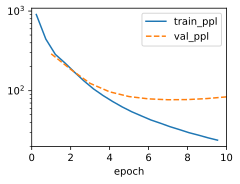

In [9]:
class GatedDeltaNetLM(d2l.RNNLM):
    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)

data = d2l.TimeMachine(batch_size=1024, num_steps=32,
                       num_train=50000, num_val=5000)
torch.manual_seed(0)
model = GatedDeltaNetLM(GatedDeltaNet(num_inputs=128, dropout=0.3),
                        vocab_size=len(data.vocab), lr=3e-4)
trainer = d2l.Trainer(max_epochs=10, gradient_clip_val=1, num_gpus=1)
model.board.yscale = 'log'
start = time.time()
trainer.fit(model, data)
secs = (time.time() - start) / 10
ppl = float(model.board.data['val_ppl'][-1].y)
params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'{"model":>15} {"val ppl":>8} {"params":>9} {"s/epoch":>8}')
print(f'{"Gated DeltaNet":>15} {ppl:>8.1f} {params:>9,} {secs:>8.1f}')

In our runs the row lands in the same band as the strongest models of
that section, mid-seventies to mid-eighties of validation
perplexity depending on framework and seed, at a comparable parameter
count, without touching that scoreboard's recipe beyond what its Mamba
row already used. At this corpus size that is all the claim we make: the
gated delta cell is *competitive as a language model* while carrying the
overwriting memory the additive family lacks. The published version of
the same comparison, at 1.3B parameters and real token budgets, has
Gated DeltaNet beating Mamba-2 and DeltaNet individually on perplexity
and recall-heavy evaluations [@Yang.Kautz.Hatamizadeh.2024], with
the two mechanisms' contributions cleanly ablatable: decay without delta
(Mamba-2) trails on recall, delta without decay (DeltaNet) trails on
modeling; the cell that does both leads on both.

### The Generalized Delta Rule

Once the transition is allowed to be "diagonal plus rank-one", Gated
DeltaNet's $\alpha_t (\mathbf{I} - \beta_t \mathbf{k}_t
\mathbf{k}_t^\top)$ is one point in a small design space, and the other
prominent occupant arrived from the RNN lineage. RWKV-7
[@Peng.Zhang.Goldstein.ea.2025] decouples every role the delta rule
ties together:

$$
\mathbf{S}_t
= \big(\mathrm{diag}(\mathbf{w}_t)
- (\mathbf{a}_t \odot \hat{\boldsymbol{\kappa}}_t)\,
  \hat{\boldsymbol{\kappa}}_t^\top\big)\, \mathbf{S}_{t-1}
+ \tilde{\mathbf{k}}_t \mathbf{v}_t^\top .
$$

Here $\mathbf{w}_t$ is a per-channel decay (the GLA rung of the ladder,
where Gated DeltaNet keeps a scalar), the unit vector
$\hat{\boldsymbol{\kappa}}_t$ is a *removal key* that need not equal the
write key $\tilde{\mathbf{k}}_t$, and $\mathbf{a}_t$ is a per-channel
in-context learning rate. The model can erase one address while writing
another, decay each coordinate at its own rate, and modulate the erase
per channel. Set all three to the delta-rule tying, no decay, removal
key equal to write key, uniform rate $\beta$, and the update collapses
back to DeltaNet; the cell below asserts as much, which is also a
useful check that the equation (stated here in this chapter's
convention; see the margin note of that section) is the
update we claim it is. We reimplement the step from the paper's
equations; the reference code, released under Apache 2.0 alongside a
line-by-line explainer, matches it in about ten lines.

In [10]:
def rwkv7_step(S, w, kappa, a, k_tilde, v):
    """One RWKV-7 state update: per-channel decay, rank-1 erase, write."""
    erase = (a * kappa)[:, None] * (kappa @ S)[None, :]
    return w[:, None] * S - erase + np.outer(k_tilde, v)

d = 8
S = rng.standard_normal((d, d))
k, v = rng.standard_normal(d), rng.standard_normal(d)
k /= np.linalg.norm(k)
b = 0.7                                    # One write strength for every role
S_rwkv = rwkv7_step(S, np.ones(d), k, b * np.ones(d), b * k, v)
S_delta = (np.eye(d) - b * np.outer(k, k)) @ S + b * np.outer(k, v)
print(f'RWKV-7, delta-rule setting: max deviation '
      f'{np.abs(S_rwkv - S_delta).max():.2e}')
assert np.abs(S_rwkv - S_delta).max() < 1e-12

RWKV-7, delta-rule setting: max deviation 4.44e-16


Two shipped families, Gated DeltaNet in Qwen3-Next and KDA in Kimi
Linear [@Kimi.Team.2025b], plus RWKV-7's own model line, all sit
within a couple of parameter-tying choices of the equation. What
in that section was a table of independent-looking models
has become, one write rule later, a family with two parents: choose the
decay structure (scalar, diagonal), choose the write rule (additive,
delta, generalized delta), and the model largely follows.

## What the Transition Can Compute

The memory story is done; a computational story has been hiding inside
it. Look at the equation once more, not as a write to a
memory but as a *linear dynamical system*: DeltaNet's transition
$\mathbf{I} - \beta_t \mathbf{k}_t \mathbf{k}_t^\top$ is the first
transition in this chapter that is not diagonal. Its spectrum is easy to
read off: eigenvalue $1 - \beta_t$ along $\mathbf{k}_t$, eigenvalue $1$
on the orthogonal complement. Every transition in
the table, by contrast, has *non-negative* eigenvalues:
decays in $(0, 1)$ can shrink a state coordinate, but can never flip its
sign. Does that limit what these models can compute, as opposed to
remember?

It does, and the cleanest witness is the humblest function in this book:
*parity*. Read a bit stream and answer whether the number of ones so far
is even. A one-dimensional recurrence solves it exactly, multiply the
state by $-1$ on every one-bit, and the sign of the state *is* the
answer, but that solution needs a transition value of $-1$. A model whose
transitions are confined to $[0, 1]$ can represent parity of the count
only through precision tricks, and finite-precision analysis says
essentially not at all [@Grazzi.Siems.Franke.ea.2025]. The
experiment below stages exactly this boundary, and two design choices,
both discovered by breaking the experiment first, matter. First, the
recurrence is *purely multiplicative*, $\mathbf{h}_t = \mathbf{a}_t
\odot \mathbf{h}_{t-1}$ from a nonzero learned $\mathbf{h}_0$, with no
input drive: parity lives in sign flips, and an additive drive hands the
model a way to bury the flip mechanism in magnitudes, which in our
trials left *both* variants at chance. Second, the sequences are short,
training at $T \le 24$: the point is the eigenvalue range, not
long-horizon optimization, which fails for its own reasons soon enough.
The two models below differ in one activation: the per-channel
transition $\mathbf{a}_t$ comes from a sigmoid, range $(0, 1)$, or from
a tanh, range $(-1, 1)$. Because success at the edge of trainability is
seed-dependent, we train three seeds per configuration and report each.

In [11]:
class MultiplicativeRNN(nn.Module):
    """h_t = a_t * h_{t-1}, elementwise; nonzero h_0; no input drive."""
    def __init__(self, act, num_hiddens=8):
        super().__init__()
        self.emb = nn.Embedding(2, num_hiddens)
        self.W_a = nn.Linear(num_hiddens, num_hiddens)
        self.h0 = nn.Parameter(torch.ones(num_hiddens)
                               + 0.1 * torch.randn(num_hiddens))
        self.head = nn.Linear(num_hiddens, 2)
        self.act = act

    def forward(self, X):
        a = self.act(self.W_a(self.emb(X)))      # (batch, T, num_hiddens)
        h = self.h0.expand(X.shape[0], -1)
        for t in range(X.shape[1]):
            h = a[:, t] * h
        return self.head(h)

def train_parity(act, T, seed, num_train=8192, num_val=2048, epochs=60,
                 batch_size=256):
    torch.manual_seed(seed)
    data_rng = np.random.default_rng(1)
    X = data_rng.integers(0, 2, (num_train + num_val, T))
    X, y = torch.tensor(X), torch.tensor(X.sum(1) % 2)
    model = MultiplicativeRNN(act)
    opt = torch.optim.Adam(model.parameters(), lr=5e-3)
    for epoch in range(epochs):
        for i in torch.randperm(num_train).split(batch_size):
            loss = F.cross_entropy(model(X[i]), y[i])
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
    with torch.no_grad():
        return float((model(X[num_train:]).argmax(-1)
                      == y[num_train:]).float().mean())

for T in [8, 16, 24]:
    for act, name in [(torch.sigmoid, 'sigmoid, a in (0,1)'),
                      (torch.tanh, 'tanh,    a in (-1,1)')]:
        accs = [train_parity(act, T, seed) for seed in range(3)]
        print(f'T={T:2d}  {name}: ' + '  '.join(f'{a:.3f}' for a in accs))

T= 8  sigmoid, a in (0,1): 0.372  0.375  0.650


T= 8  tanh,    a in (-1,1): 1.000  1.000  1.000


T=16  sigmoid, a in (0,1): 0.486  0.497  0.497


T=16  tanh,    a in (-1,1): 1.000  1.000  1.000


T=24  sigmoid, a in (0,1): 0.517  0.517  0.483


T=24  tanh,    a in (-1,1): 0.517  1.000  1.000


The separation is stark. The non-negative model solves parity in none of
our runs: its best seeds reach only the $0.6$--$0.7$ range, at $T = 8$,
where magnitudes can weakly encode the count, and from $T = 16$ on every
run sits at chance; more data or more epochs cannot supply what the
dynamics lacks, a way to flip a sign. The $(-1, 1)$ model solves parity
on every seed at the shortest length and then runs into a different
wall: optimization grows less reliable with length. In our runs, failing
seeds appear from $T = 16$ in one framework and by $T = 24$ in both,
each failed seed at chance while the surviving seeds still find the
sign-flip solution; which seeds fail moves between frameworks and
re-runs, and only the pattern, reliability decaying with $T$, is stable.
Keep the two walls distinct, because they have different remedies. The
sigmoid model fails for *representational* reasons: by the
finite-precision result cited below, no parameter setting of a
fixed-size recurrence with non-negative transitions computes parity at
arbitrary length, and our short-$T$ runs show the failure already in
force at toy scale. The tanh model at larger $T$ fails, when it fails,
for *optimization* reasons: the solution exists (set every one-bit's
transition to $-1$; done), but gradient descent through a product of
many near-sign-flips has a hard time finding it. The next cell shows the
solution existing regardless of length, by setting the weights by hand.

### The Reflection in the Delta Rule

What has this to do with DeltaNet? The transition
$\mathbf{I} - \beta \mathbf{k} \mathbf{k}^\top$ carries the same
capability, hidden behind the range of $\beta$. Its eigenvalue along
$\mathbf{k}$ is $1 - \beta$: for $\beta \in (0, 1)$, always positive, a
partial erase; at $\beta = 1$, exactly zero, a *projection* that deletes
the $\mathbf{k}$-component outright; and if $\beta$ were allowed up to
$2$, the eigenvalue reaches $-1$ and the transition becomes a
*reflection*, a sign flip along $\mathbf{k}$ and identity elsewhere, a
Householder transformation. We verify the mechanism with no training at
all, a delta cell whose weights we set by hand: state initialized to
$\mathbf{k}$, transition applied on every one-bit, parity read from the
sign of $\mathbf{k}^\top \mathbf{h}_T$. One caution from our own
attempts: this *must* be a hand-set demonstration. The trained analogue
with a single learnable reflection axis is an optimization trap, it can
represent parity but in our runs never learned it at any $T$, so we
teach the mechanism mechanistically and let the diagonal experiment
above carry the trained evidence.

In [12]:
d = 6
k = rng.standard_normal(d)
k /= np.linalg.norm(k)
for b in [0.5, 1.0, 1.5, 2.0]:
    eigs = np.sort(np.linalg.eigvalsh(np.eye(d) - b * np.outer(k, k)))
    print(f'beta = {b:.1f}: eigenvalues {eigs[0]:+.1f} (along k), '
          f'{eigs[-1]:+.1f} (elsewhere)')

for T in [8, 24, 64]:
    bits = rng.integers(0, 2, (2000, T))
    parity = bits.sum(1) % 2
    for b, tag in [(1.0, 'projection'), (2.0, 'reflection')]:
        h = np.tile(k, (len(bits), 1))            # h_0 = k
        for t in range(T):                        # (I - beta k k^T) on one-bits
            h -= (b * bits[:, t])[:, None] * (h @ k)[:, None] * k
        acc = ((h @ k < 0).astype(int) == parity).mean()
        print(f'T = {T:2d}, beta = {b:.0f} ({tag}): parity accuracy {acc:.3f}')

beta = 0.5: eigenvalues +0.5 (along k), +1.0 (elsewhere)
beta = 1.0: eigenvalues -0.0 (along k), +1.0 (elsewhere)
beta = 1.5: eigenvalues -0.5 (along k), +1.0 (elsewhere)
beta = 2.0: eigenvalues -1.0 (along k), +1.0 (elsewhere)
T =  8, beta = 1 (projection): parity accuracy 0.529
T =  8, beta = 2 (reflection): parity accuracy 1.000
T = 24, beta = 1 (projection): parity accuracy 0.518
T = 24, beta = 2 (reflection): parity accuracy 1.000
T = 64, beta = 1 (projection): parity accuracy 0.501
T = 64, beta = 2 (reflection): parity accuracy 1.000


The projection erases the very component that counts, accuracy at
chance at every length, while the reflection computes parity *exactly*
at $T = 64$ as easily as at $T = 8$: no optimization horizon, because
nothing was optimized. This one eigenvalue is the entire content of a
design flag you will meet in production DeltaNet code, `allow_neg_eigval`,
which simply doubles the gate to $\beta_t = 2\,\sigma(\cdot) \in (0, 2)$.
Note that the interval is open: for finite logits $2\sigma(\cdot)$
approaches but never reaches $2$, so the exact reflection we just ran by
hand is a *boundary construction*, the limit of the trainable family
rather than a member of it — close enough for the capability, since an
eigenvalue near $-1$ still flips signs, at the price of a slow decay of
the tracked component. @Grazzi.Siems.Franke.ea.2025 supply the
theory and the scaled-up measurements: for finite-precision linear
recurrences with fixed state size, transitions confined to non-negative
spectra provably cannot solve parity at arbitrary input length, and
trained DeltaNet variants jump from near-zero length generalization on
parity to essentially perfect once $\beta$ may exceed $1$, with modular
arithmetic improving in step.

### The Ladder, and Its Ceiling

Climbing one more rung: a reflection along one axis per token buys
sign-flip state, but composing *rotations*, tracking a permutation as it
composes, say the word problem of the symmetric group $S_3$, needs
transitions that mix several directions at once. DeltaProduct
[@Siems.Carstensen.Zela.ea.2025] gets there by taking $n_h$ delta
micro-steps per token, making the transition a product of $n_h$
Householder-like factors, rank-$n_h$ beyond diagonal, which
interpolates between DeltaNet ($n_h = 1$) and a dense (but
norm-bounded, hence stable) transition; on group word problems the
reachable groups and the length extrapolation grow with $n_h$, at
$n_h$ times the write cost. And there, as of the 2024--2025 results
cited here, the ladder stops.
@Merrill.Petty.Sabharwal.2024 place fixed-depth, log-precision
transformers, S4, and Mamba in the complexity class $\mathsf{TC}^0$:
under standard conjectures, no such model, and no diagonal-transition
recurrence under the same assumptions, solves the word problem of $S_5$
at arbitrary length. That group is the algebra those authors put forward
as the shared kernel of state tracking, tasks like following chess
positions, evaluating code, or tracking entities — a motivation drawn
from the cited work, not a proved reduction of any of those full tasks.
A plain nonlinear RNN, paying the sequential price this
chapter has been trying to avoid, solves the $S_5$ word problem with one
layer. Their phrase for the diagonal families' predicament: an
*illusion of state*,
a recurrence that carries a state but cannot compose with it. The
delta-rule rungs recover a real, if bounded, slice of that power
without giving up parallel training; at the time of writing (2025), no
published rung climbs higher without giving up the parallel schedule.
the table summarizes the ladder with
the evidence this section put on the table.

<!-- tbl-caption:What a transition can track. Each rung adds structure to $\mathbf{D}_t$ in the equation; the right column names the cheapest capability the rung unlocks, per this section's experiments and the cited theory. -->

| transition $\mathbf{D}_t$ | eigenvalues | models | unlocks |
|:--|:--|:--|:--|
| $\mathbf{I}$ | all $1$ | linear attention | accumulation only |
| scalar or diagonal, $(0, 1)$ | non-negative | RetNet, Mamba-2, GLA | forgetting; parity out of reach (fixed state, finite precision, arbitrary length) |
| diagonal, $(-1, 1)$ | signed | negative-eigenvalue variants | parity, via sign flips |
| $\alpha_t(\mathbf{I} - \beta_t \mathbf{k}_t \mathbf{k}_t^\top)$, $\beta_t \in (0, 1)$ | non-negative | DeltaNet, Gated DeltaNet | targeted erasure (this section's memory story) |
| same, $\beta_t \in (0, 2)$ | signed | `allow_neg_eigval` variants, RWKV-7 | sign flips: parity (exact reflection at the $\beta = 2$ boundary) |
| product of $n_h$ Householders | signed, rank-$n_h$ | DeltaProduct | composing reflections: group word problems ($S_3$, $S_4$) |
| dense nonlinear | unrestricted | plain RNN (that section) | $S_5$ and beyond, at sequential cost |

Where does this leave the family? With a memory that can edit, a decay
that can forget, a training schedule that runs on matmuls, and a
transition that computes more than any diagonal model, yet still a
fixed-size state with the capacity ceiling measured in
that section, and still, under $\mathsf{TC}^0$, shy of
what a true recurrent state can track. Both residual gaps point to the
same production answer, pairing these layers with a few attention
layers, and that is that section. Before the hybrids, though,
one more unification is owed: the delta rule arrived here as *one* SGD
step on *one* loss. that section asks the general
question, what if a sequence layer is an optimizer, full stop, and
re-derives this whole chapter from it.

**What this section's experiments do and do not show.** The overwrite
cells are diagnostics under a stated restriction, write addresses
computed from the key token alone, and show that within it the additive
write superposes and the delta write does not, both mechanistically and
after end-to-end training; they do not bound what an architecture with
pair-dependent addressing can learn. The WY check is an identity,
verified to floating-point tolerance. The scoreboard row is one seeded
run per framework on one small corpus; the conclusions at 1.3B scale
belong to the cited paper. The parity sweep shows a representational
wall for non-negative transitions at toy scale — the arbitrary-length
statement is the cited theorem's, with its fixed-state and
finite-precision assumptions — and a seed-dependent optimization horizon
for signed ones; the hand-set reflection is a mechanism demonstration,
not a trained result.

## Summary

An additive matrix memory cannot re-bind a key: after $R$ writes to the
same key it returns the superposition of all $R$ values, and recall of
the latest collapses like guesswork, a failure that survives end-to-end
training whenever write addresses must be reused (and one that decay
cannot fix, since decay discounts by age, not by key). The delta rule
reads before writing and stores only the correction,
$\mathbf{S}_t = \mathbf{S}_{t-1} - \beta_t \mathbf{k}_t
(\mathbf{k}_t^\top \mathbf{S}_{t-1} - \mathbf{v}_t^\top)$, which is one
SGD step on the recall loss $\frac{1}{2}\|\mathbf{S}^\top \mathbf{k}_t -
\mathbf{v}_t\|^2$ taken inside the forward pass, Widrow--Hoff's 1960
update running as a neural memory, holding recall at $1.000$ under
overwrites in both our mechanistic and trained experiments. Its
transition $\mathbf{I} - \beta_t \mathbf{k}_t \mathbf{k}_t^\top$ is not
diagonal, so chunked training replaces `segsum` with a unit-triangular
solve, the WY trick, verified here equal to the recurrence at every
chunk size. Gated DeltaNet adds decoupled forgetting,
$\alpha_t(\mathbf{I} - \beta_t \mathbf{k}_t \mathbf{k}_t^\top)$, its
gate playing the role of AdamW's decoupled weight decay, and lands in
the strongest band of our language-modeling scoreboard; RWKV-7
generalizes the same cell with per-channel decay and a removal key
decoupled from the write key. The
non-diagonal transition also computes: eigenvalue $1 - \beta_t$ along
the key means $\beta > 1$ buys sign flips, up to the exact reflection at
the boundary $\beta = 2$, and with them parity
(the `allow_neg_eigval` flag); products of reflections (DeltaProduct)
buy group word problems, and the $\mathsf{TC}^0$ ceiling marks where
parallel-trainable recurrences still end.

## Exercises

1. **[short-code]** In the trained overwrite experiment of
   that section,
   change the write-strength gate from $\sigma(\cdot)$ to
   $2\sigma(\cdot)$, so that $\beta_t \in (0, 2)$, and rerun the delta
   sweep. Does recall change? Explain why the overwrite task gives the
   model no reason to use $\beta > 1$, and predict, before running
   anything, a task from this section that would.
1. **[short-code]** The mechanistic experiment of
   that section uses
   orthonormal keys. Re-run it with random unit-norm keys (skip the QR
   step) and measure, separately, recall of keys that were just
   overwritten and recall of the *other* keys. Use
   the equation to explain why the delta write now
   damages neighboring bindings, and why the damage grows with key
   overlap.
1. **[short-code]** Repeat the capacity sweep of
   that section with the
   delta write, storing $n$ pairs under $n$ *distinct* random keys. Show
   that the delta rule obeys essentially the same $(n-1)/d_k$ error law.
   Reconcile this with this section: which failure does the delta rule
   fix, crowding or staleness?
1. **[short-code]** Replace `solve_triangular` in `delta_chunked` with
   an explicit forward-substitution loop over the chunk and verify
   agreement. Count
   the FLOPs of the solve against the two matmuls that surround it, at
   chunk size $C$ and dimensions $d_k = d_v = d$: for which $C/d$ ratio
   does the solve stop being negligible?
1. **[extended]** Extend `delta_chunked` to the gated update
   the equation.
   Hint: fold the running product of decays $\alpha$ into the keys and
   values entering each chunk, in log space as in
   that section, and rescale the carried state at the
   boundary; verify against a token loop.
1. **[extended]** Two reflections compose into a rotation: taking
   $n_h = 2$ delta
   micro-steps per token yields transitions that can rotate a plane by
   an input-dependent angle, which is enough to track the word problem
   of $S_3$ (three-element permutation composition). Following
   that section, hand-set a two-step cell whose two
   reflection axes realize each generator of $S_3$ and verify perfect
   tracking on random words of length up to $64$. What does your
   construction need that a single micro-step ($n_h = 1$) cannot
   provide?

[Discussions](https://d2l.discourse.group/)